<a href="https://colab.research.google.com/github/murtazaarsh7/ml_model/blob/main/k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('/content/dataset.csv')

In [ ]:
df.shape

(150, 2)

In [ ]:
df

,x,y
0,0.496714,4.861736
1,0.647689,6.523030
2,-0.234153,4.765863
3,1.579213,5.767435
4,-0.469474,5.542560
...,...,...
145,2.849410,-0.473012
146,3.993856,0.080816
147,2.285222,-0.161692
148,2.497526,0.891180


In [ ]:
import matplotlib.pyplot as plt

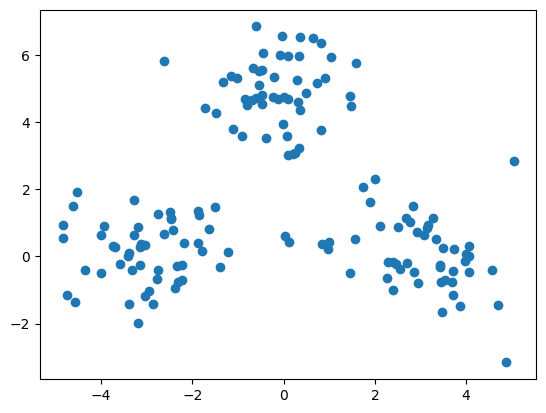

In [ ]:
plt.scatter(df['x'],df['y'])

In [ ]:
centroids=[(-5,-5),(1,4),(7,-6)]

In [ ]:
import random

In [ ]:
class kmeans:
  def __init__(self,n_clusters=2,max_iter=100):
    self.n_clusters=n_clusters
    self.max_iter=max_iter
  def fit(self,x):
    index = random.sample(range(0,x.shape[0]),self.n_clusters)
    self.centroids=x[index]
    for i in range(self.max_iter):
      #assign cluster
      cluster_group=self.assign_cluster(x)
      old_centroids=self.centroids
      #move_centroids
      self.centroids=self.move_centroids(cluster_group,x)
      #check finish
      if (old_centroids==self.centroids).all():
        break
    return cluster_group

  def move_centroids(self,cluster_group,x):
    new_centroids=[]
    cluster_type=np.unique(cluster_group)
    for typo in cluster_type:
      new_centroids.append(x[cluster_group==typo].mean(axis=0))
    return np.array(new_centroids)
  def assign_cluster(self,x):
    cluster_group=[]
    for row in x:
      distances=[]
      for centroid in self.centroids:
        distances.append(np.sqrt(np.dot(row-centroid,row-centroid)))
        min_dist=min(distances)
        index_pos=distances.index(min_dist)

      cluster_group.append(index_pos)
    return np.array(cluster_group)

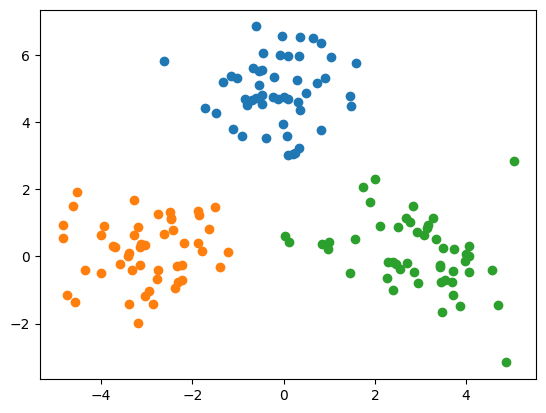

In [ ]:
model = kmeans(n_clusters=3,max_iter=50)
x = df.values
y_means=model.fit(x)
plt.scatter(x[y_means==0,0],x[y_means==0,1])
plt.scatter(x[y_means==1,0],x[y_means==1,1])
plt.scatter(x[y_means==2,0],x[y_means==2,1])